# WMS / WMTS — read an OGC map layer into a `Dataset`

`Dataset.from_wms` and `Dataset.from_wmts` pull an OGC **map-service** layer into a
georeferenced [`Dataset`](../../reference/dataset/index.md) using GDAL's native
WMS / WMTS drivers — the imagery siblings of
[`from_wcs`](../../reference/dataset/index.md) and `from_ogc_coverages`.

A **WMS** (`GetMap`) or **WMTS** (tiled `GetTile`) service renders the data
server-side and returns an **image**, so the result is a georeferenced **RGB / RGBA
raster — a picture**, not scientific pixel values. Reach for these when you want the
*imagery* (satellite mosaics, rendered basemap-as-data, NASA GIBS true-colour); reach
for `from_wcs` / `from_ogc_coverages` when you want the underlying values.

> **Network required.** This notebook hits **live** public endpoints — NASA GIBS
> (WMTS) and terrestris OSM-WMS. Because it depends on external services it is
> *excluded* from the CI notebook build (like the STAC cloud notebook), so a service
> outage never breaks the docs.

## Setup

We only need `matplotlib` to show the returned images and `Dataset` itself — the
readers take plain URLs, so there is no local data to load. `show_rgb` draws a
returned raster on its real lon/lat extent (the readers hand back `uint8` RGB(A),
so we just move the band axis last and `imshow` it).

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np

from pyramids.dataset import Dataset


def show_rgb(ds, title):
    # Plot a returned RGB(A) Dataset on its georeferenced lon/lat extent.
    arr = np.asarray(ds.read_array())              # (bands, rows, cols)
    rgb = np.moveaxis(arr[:3], 0, -1).astype("uint8")
    minx, miny, maxx, maxy = (float(v) for v in ds.bbox)
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(rgb, extent=(minx, maxx, miny, maxy))
    ax.set(title=title, xlabel="longitude", ylabel="latitude")
    plt.show()

2026-07-07 06:32:21 | INFO | pyramids.base.config | Logging is configured.


## 1. WMS `GetMap` — render a window

`from_wms` builds a GDAL `<GDAL_WMS>` `GetMap` descriptor whose request window *is*
the `bbox` you pass, rendered in the requested `crs` (no client-side reprojection —
the server renders that exact extent). You size the output with **either** an
explicit `size=(width, height)` **or** a `resolution=` (pixel size in the bbox CRS
units) — exactly one is required.

Here we render a small window of the terrestris **OpenStreetMap** WMS layer over
the Netherlands as a 512×512 image.

In [2]:
OSM = "https://ows.terrestris.de/osm/service?"
BBOX = (5.0, 51.0, 6.0, 52.0)   # (minx, miny, maxx, maxy) in lon/lat

osm = Dataset.from_wms(OSM, layers="OSM-WMS", bbox=BBOX, size=(512, 512))
osm.shape, [round(v, 3) for v in osm.bbox], osm.epsg

((3, 512, 512), [5.0, 51.0, 6.0, 52.0], 4326)

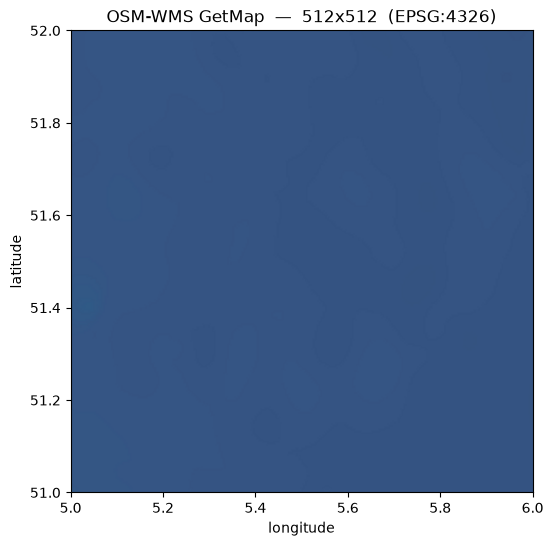

In [3]:
show_rgb(osm, "OSM-WMS GetMap  —  512x512  (EPSG:4326)")

The result is a plain `Dataset`: a `(3, 512, 512)` RGB raster on the requested
`[5, 51, 6, 52]` extent in `EPSG:4326`. It behaves like any other raster — you can
crop, reproject, or write it to a GeoTIFF with `to_file(...)`.

### `size` vs `resolution`

| argument | meaning | example |
|---|---|---|
| `size=(w, h)` | exact output image size in pixels | `size=(512, 512)` |
| `resolution=r` | pixel size in the bbox CRS units, divided into the extent | `resolution=0.02` → 50×50 |

The same 1°×1° window at `resolution=0.02` (≈ 0.02° pixels) comes back 50×50:

In [4]:
coarse = Dataset.from_wms(OSM, layers="OSM-WMS", bbox=BBOX, resolution=0.02)
coarse.shape

(3, 50, 50)

## 2. WMTS — crop a tiled pyramid

A **WMTS** layer is a pre-rendered *tile pyramid*. `from_wmts` opens the whole layer
as a georeferenced pyramid (with overviews) from its `GetCapabilities` URL, then
crops your `bbox` out of it — reprojecting the bbox into the layer's native CRS with
`pyproj`, just like `from_wcs` windows a coverage.

We crop a window over the Netherlands from NASA **GIBS** MODIS/Terra true-colour.
`resolution=` sets the output pixel size and lets GDAL read from the matching
overview level (so a wide bbox does not pull the finest, globe-sized level).

In [5]:
GIBS = (
    "https://gibs.earthdata.nasa.gov/wmts/epsg4326/best/1.0.0/"
    "WMTSCapabilities.xml"
)

truecolor = Dataset.from_wmts(
    GIBS,
    layer="MODIS_Terra_CorrectedReflectance_TrueColor",
    bbox=BBOX,
    resolution=0.02,
)
truecolor.shape, [round(v, 2) for v in truecolor.bbox], truecolor.epsg

((4, 50, 50), [5.0, 51.0, 6.0, 52.0], 4326)

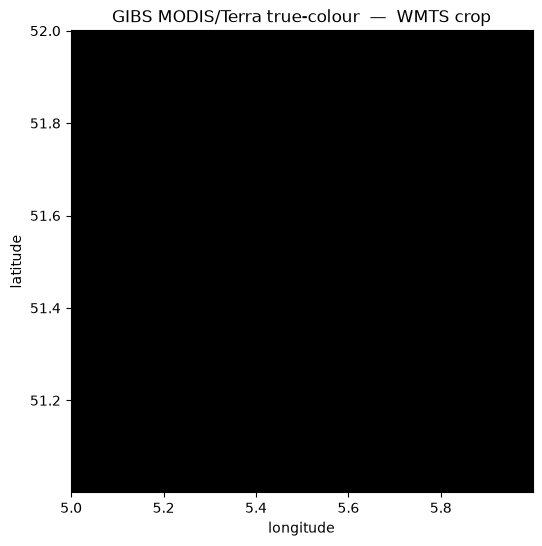

In [6]:
show_rgb(truecolor, "GIBS MODIS/Terra true-colour  —  WMTS crop")

The layer is served as RGBA and reports its CRS as OGC `CRS84` (lon/lat WGS 84);
pyramids resolves that to `EPSG:4326`, so the crop reads back as a normal
`EPSG:4326` raster on the requested extent.

### Picking a layer

A WMTS endpoint can advertise *thousands* of layers. If you pass a `layer` the
service does not advertise, `from_wmts` raises a `ValueError` that lists the
available ones — so a typo fails fast with a helpful message instead of an opaque
driver error.

In [7]:
try:
    Dataset.from_wmts(GIBS, layer="NoSuchLayer", bbox=BBOX, resolution=0.1)
except ValueError as exc:
    print(str(exc)[:160], "…")

layer 'NoSuchLayer' is not advertised by 'https://gibs.earthdata.nasa.gov/wmts/epsg4326/best/1.0.0/WMTSCapabilities.xml'. Available layers: ['ACTIVATE_HU-25_Fal …


## 3. Imagery, not data values

Both readers return **server-rendered pixels** — the values are RGB(A) colours the
service chose for display, *not* the physical quantity behind them. Averaging the
red band of a true-colour tile is meaningless; it is a picture.

When you need the **underlying values** (elevation, reflectance, a soil property) to
compute on, use the coverage readers instead:

| you want… | reader |
|---|---|
| a rendered map image (basemap, true-colour) | `from_wms` / `from_wmts` |
| coverage **data values** (classic OGC WCS) | `Dataset.from_wcs` |
| coverage **data values** (OGC API – Coverages) | `Dataset.from_ogc_coverages` |

## Takeaway

- `from_wms` renders a `GetMap` window in the requested CRS; size it with `size=`
  **or** `resolution=`.
- `from_wmts` crops a tiled pyramid, reprojecting your bbox into the layer's native
  CRS and reading the overview level that matches `resolution=`.
- Both hand back an ordinary georeferenced `Dataset` of **rendered RGB(A) imagery** —
  crop, reproject, or `to_file(...)` it like any other raster.
- For scientific **values** rather than a picture, use `from_wcs` /
  `from_ogc_coverages`.

**See also:** the `Dataset` API reference for the full `from_wms` / `from_wmts`
parameter list (`image_format`, `version`, `bands`, `tile_matrix_set`, `output_crs`,
`auth`, `timeout`, …).